# 06 — Live YOLOv8 Detection Demo

Run this notebook from the repository using the project Python environment. If the packages are missing, run `python -m pip install -r requirements.txt` in the environment selected as this notebook's kernel. The demo defaults to a held-out test image; you can also upload an image, view detections inline, and inspect predicted identities and confidence scores.

In [1]:
from pathlib import Path
import io

def find_repo_root(start: Path) -> Path:
    for candidate in (start.resolve(), *start.resolve().parents):
        if (candidate / "detection_dataset" / "dataset.yaml").is_file():
            return candidate
    raise RuntimeError("Could not find the repository root. Run this notebook from inside the project.")

REPO_ROOT = find_repo_root(Path.cwd())
DATASET_DIR = REPO_ROOT / "detection_dataset"
TEST_IMAGE_DIR = DATASET_DIR / "test" / "images"
CHECKPOINT = REPO_ROOT / "runs" / "detect" / "celeba_yolov8n_milestone2" / "weights" / "best.pt"

if not CHECKPOINT.is_file():
    raise FileNotFoundError(f"Fine-tuned checkpoint not found: {CHECKPOINT}")
if not TEST_IMAGE_DIR.is_dir():
    raise FileNotFoundError(f"Held-out test images not found: {TEST_IMAGE_DIR}")

from IPython.display import display
from PIL import Image
import ipywidgets as widgets
from ultralytics import YOLO

print(f"Repository: {REPO_ROOT}")
print(f"Checkpoint: {CHECKPOINT.relative_to(REPO_ROOT)}")

Repository: C:\Users\andre\Documents\GitHub\ie7615-group-02-project1
Checkpoint: runs\detect\celeba_yolov8n_milestone2\weights\best.pt


## Load the fine-tuned detector

The bundled best checkpoint is used as-is; this demo performs inference only and does not retrain or alter the held-out test set.

In [2]:
model = YOLO(str(CHECKPOINT))
image_extensions = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
TEST_IMAGES = sorted(
    path for path in TEST_IMAGE_DIR.iterdir()
    if path.is_file() and path.suffix.lower() in image_extensions
)
if not TEST_IMAGES:
    raise FileNotFoundError(f"No held-out images found in {TEST_IMAGE_DIR}")

print(f"Loaded YOLOv8 checkpoint with {len(model.names)} identity classes.")
print(f"Available held-out images: {len(TEST_IMAGES)}")
print(", ".join(path.name for path in TEST_IMAGES))

Loaded YOLOv8 checkpoint with 13 identity classes.
Available held-out images: 5
grid_0006_aug1.jpg, grid_0006_aug2.jpg, grid_0006_aug3.jpg, grid_0006_aug4.jpg, grid_0006_orig.jpg


## Choose an image

Select a bundled held-out image or switch to upload mode and choose a local image file. The upload control is provided by `ipywidgets`.

In [6]:
default_test_image = next(
    (path for path in TEST_IMAGES if path.stem.endswith("_orig")),
    TEST_IMAGES[0],
)
source_mode = widgets.ToggleButtons(
    options=[("Held-out test image", "test"), ("Upload an image", "upload")],
    value="test",
    description="Input:",
)
test_image_picker = widgets.Dropdown(
    options=[(path.name, str(path)) for path in TEST_IMAGES],
    value=str(default_test_image),
    description="Test image:",
)
upload_control = widgets.FileUpload(accept="image/*", multiple=False, description="Choose image")
confidence_slider = widgets.FloatSlider(
    value=0.03,
    min=0.001,
    max=0.25,
    step=0.005,
    description="Confidence:",
    readout_format=".3f",
    continuous_update=False,
)
display(source_mode, test_image_picker, upload_control, confidence_slider)

ToggleButtons(description='Input:', options=(('Held-out test image', 'test'), ('Upload an image', 'upload')), …

Dropdown(description='Test image:', index=4, options=(('grid_0006_aug1.jpg', 'C:\\Users\\andre\\Documents\\Git…

FileUpload(value=(), accept='image/*', description='Choose image')

FloatSlider(value=0.03, continuous_update=False, description='Confidence:', max=0.25, min=0.001, readout_forma…

Selected: grid_0006_orig.jpg (640 x 640)


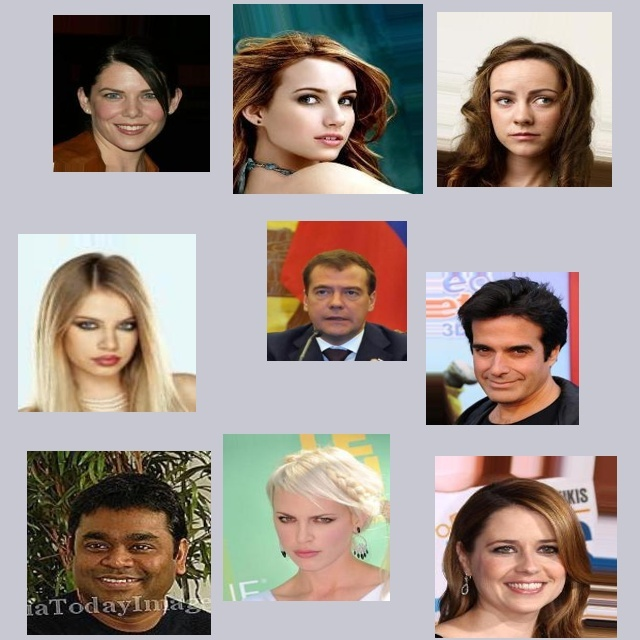

In [8]:
if source_mode.value == "test":
    selected_image = test_image_picker.value
    selected_image_name = Path(selected_image).name
    preview = Image.open(selected_image).convert("RGB")
else:
    uploaded = upload_control.value
    if not uploaded:
        raise ValueError("Choose an image with the upload control, then rerun this cell.")
    if isinstance(uploaded, dict):
        upload_item = uploaded if "content" in uploaded else next(iter(uploaded.values()))
    else:
        upload_item = uploaded[0]
    selected_image_name = upload_item.get("name", "uploaded image")
    preview = Image.open(io.BytesIO(bytes(upload_item["content"]))).convert("RGB")
    selected_image = preview

print(f"Selected: {selected_image_name} ({preview.width} x {preview.height})")
display(preview)

## Run detection

Predicted boxes are rendered with the model's class label and confidence score. Adjust the confidence or NMS IoU values below to explore inference behavior.

Detections: 3 (showing at most the 12 highest-confidence predictions)
identity_3 | confidence=0.198 | xyxy=[268.1, 220.6, 408.8, 363.2]
identity_3 | confidence=0.047 | xyxy=[427.3, 271.6, 578.6, 424.8]
identity_7 | confidence=0.034 | xyxy=[26.8, 449.5, 210.8, 634.9]


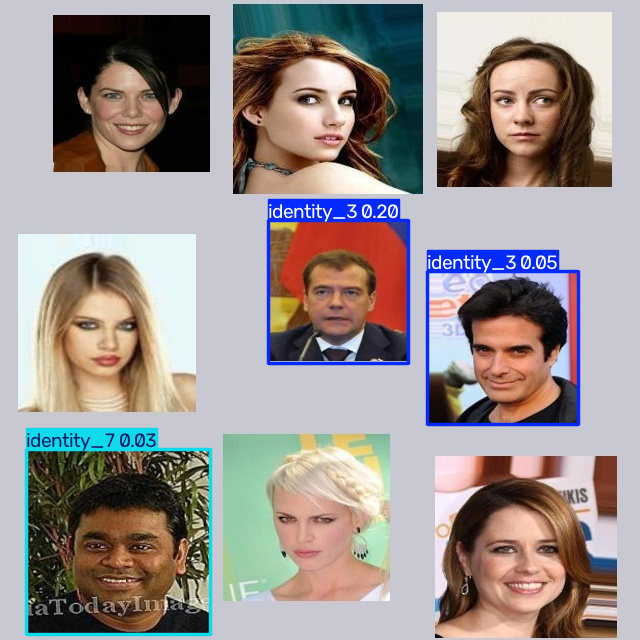

In [9]:
CONFIDENCE = float(confidence_slider.value)
NMS_IOU = 0.50
results = model.predict(
    source=selected_image,
    imgsz=640,
    conf=CONFIDENCE,
    iou=NMS_IOU,
    max_det=50,
    verbose=False,
)[0]

if results.boxes is None or len(results.boxes) == 0:
    print("No detections at the current confidence threshold. Try lowering the slider.")
else:
    boxes = sorted(results.boxes, key=lambda box: float(box.conf.item()), reverse=True)
    print(f"Detections: {len(boxes)} (showing at most the 12 highest-confidence predictions)")
    for box in boxes[:12]:
        class_id = int(box.cls.item())
        confidence = float(box.conf.item())
        coordinates = [round(value, 1) for value in box.xyxy[0].tolist()]
        print(f"{model.names[class_id]} | confidence={confidence:.3f} | xyxy={coordinates}")
    if len(boxes) > 12:
        print(f"... {len(boxes) - 12} additional predictions not listed")
    annotated_bgr = results.plot()
    display(Image.fromarray(annotated_bgr[:, :, ::-1]))